<a href="https://colab.research.google.com/github/liangwan2023/MachineLearning/blob/main/Assignment3_decisiontree.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# Assignment3_DecisionTree
#Install/import library
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

from sklearn.feature_selection import SelectKBest, mutual_info_classif, f_classif
from sklearn.tree import DecisionTreeClassifier

from sklearn.metrics import (
    confusion_matrix, ConfusionMatrixDisplay,
    classification_report, accuracy_score,
    balanced_accuracy_score, f1_score
)

import matplotlib.pyplot as plt

In [2]:
# load the dataset
df = pd.read_csv("Dry_Bean_Dataset.csv")
df.head()

,Area,Perimeter,MajorAxisLength,MinorAxisLength,AspectRation,Eccentricity,ConvexArea,EquivDiameter,Extent,Solidity,roundness,Compactness,ShapeFactor1,ShapeFactor2,ShapeFactor3,ShapeFactor4,Class
0,28395,610.291,208.178117,173.888747,1.197191,0.549812,28715,190.141097,0.763923,0.988856,0.958027,0.913358,0.007332,0.003147,0.834222,0.998724,SEKER
1,28734,638.018,200.524796,182.734419,1.097356,0.411785,29172,191.272751,0.783968,0.984986,0.887034,0.953861,0.006979,0.003564,0.909851,0.998430,SEKER
2,29380,624.110,212.826130,175.931143,1.209713,0.562727,29690,193.410904,0.778113,0.989559,0.947849,0.908774,0.007244,0.003048,0.825871,0.999066,SEKER
3,30008,645.884,210.557999,182.516516,1.153638,0.498616,30724,195.467062,0.782681,0.976696,0.903936,0.928329,0.007017,0.003215,0.861794,0.994199,SEKER
4,30140,620.134,201.847882,190.279279,1.060798,0.333680,30417,195.896503,0.773098,0.990893,0.984877,0.970516,0.006697,0.003665,0.941900,0.999166,SEKER


In [3]:
# 1) Feature Selection
# 1.1 Explore the dataset
print(df.shape)
print(df.columns)
df.info()
df.describe(include="all")

(13611, 17)
Index(['Area', 'Perimeter', 'MajorAxisLength', 'MinorAxisLength',
       'AspectRation', 'Eccentricity', 'ConvexArea', 'EquivDiameter', 'Extent',
       'Solidity', 'roundness', 'Compactness', 'ShapeFactor1', 'ShapeFactor2',
       'ShapeFactor3', 'ShapeFactor4', 'Class'],
      dtype='object')
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13611 entries, 0 to 13610
Data columns (total 17 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Area             13611 non-null  int64  
 1   Perimeter        13611 non-null  float64
 2   MajorAxisLength  13611 non-null  float64
 3   MinorAxisLength  13611 non-null  float64
 4   AspectRation     13611 non-null  float64
 5   Eccentricity     13611 non-null  float64
 6   ConvexArea       13611 non-null  int64  
 7   EquivDiameter    13611 non-null  float64
 8   Extent           13611 non-null  float64
 9   Solidity         13611 non-null  float64
 10  roundness        13611 non

,Area,Perimeter,MajorAxisLength,MinorAxisLength,AspectRation,Eccentricity,ConvexArea,EquivDiameter,Extent,Solidity,roundness,Compactness,ShapeFactor1,ShapeFactor2,ShapeFactor3,ShapeFactor4,Class
count,13611.000000,13611.000000,13611.000000,13611.000000,13611.000000,13611.000000,13611.000000,13611.000000,13611.000000,13611.000000,13611.000000,13611.000000,13611.000000,13611.000000,13611.000000,13611.000000,13611
unique,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,7
top,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,DERMASON
freq,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3546
mean,53048.284549,855.283459,320.141867,202.270714,1.583242,0.750895,53768.200206,253.064220,0.749733,0.987143,0.873282,0.799864,0.006564,0.001716,0.643590,0.995063,NaN
std,29324.095717,214.289696,85.694186,44.970091,0.246678,0.092002,29774.915817,59.177120,0.049086,0.004660,0.059520,0.061713,0.001128,0.000596,0.098996,0.004366,NaN
min,20420.000000,524.736000,183.601165,122.512653,1.024868,0.218951,20684.000000,161.243764,0.555315,0.919246,0.489618,0.640577,0.002778,0.000564,0.410339,0.947687,NaN
25%,36328.000000,703.523500,253.303633,175.848170,1.432307,0.715928,36714.500000,215.068003,0.718634,0.985670,0.832096,0.762469,0.005900,0.001154,0.581359,0.993703,NaN
50%,44652.000000,794.941000,296.883367,192.431733,1.551124,0.764441,45178.000000,238.438026,0.759859,0.988283,0.883157,0.801277,0.006645,0.001694,0.642044,0.996386,NaN
75%,61332.000000,977.213000,376.495012,217.031741,1.707109,0.810466,62294.000000,279.446467,0.786851,0.990013,0.916869,0.834270,0.007271,0.002170,0.696006,0.997883,NaN


In [4]:
# 1.2 count the Class;use value_count function to get the class number and proportion.
df["Class"].value_counts()
df["Class"].value_counts(normalize=True)

,proportion
Class,
DERMASON,0.260525
SIRA,0.193667
SEKER,0.148924
HOROZ,0.141650
CALI,0.119756
BARBUNYA,0.097127
BOMBAY,0.038351


In [5]:
# Check If there are missing values
df.isna().sum().sort_values(ascending=False).head(10)

,0
Area,0
Perimeter,0
MajorAxisLength,0
MinorAxisLength,0
AspectRation,0
Eccentricity,0
ConvexArea,0
EquivDiameter,0
Extent,0
Solidity,0


In [6]:
#  Split X/Y
X = df.drop(columns=["Class"])
y = df["Class"]

In [7]:
# 1.3 Pick the top 3 features selection method
selector = SelectKBest(score_func=mutual_info_classif, k=3)
selector.fit(X, y)

mask = selector.get_support()
top3_features = X.columns[mask].tolist()
scores = selector.scores_

feat_scores = pd.Series(scores, index=X.columns).sort_values(ascending=False)
print("Top 3 features (MI):", top3_features)
feat_scores.head(10)

Top 3 features (MI): ['Perimeter', 'ConvexArea', 'EquivDiameter']


,0
Perimeter,1.056964
ConvexArea,1.039069
EquivDiameter,1.037364
Area,1.036671
MajorAxisLength,0.996402
ShapeFactor2,0.954724
ShapeFactor1,0.931088
MinorAxisLength,0.928023
Compactness,0.835597
ShapeFactor3,0.835584


In [8]:
# ANOVA top 3
selector_f = SelectKBest(score_func=f_classif, k=3)
selector_f.fit(X, y)

top3_features_f = X.columns[selector_f.get_support()].tolist()
print("Top 3 features (ANOVA):", top3_features_f)

Top 3 features (ANOVA): ['Area', 'ConvexArea', 'EquivDiameter']


In [9]:
# 2) Data Normalization(combine in pipeline)
# 3) Model Building: Decision Tree using selected features
# 3.1 Create a dataset with only top 3
X3 = X[top3_features]


In [10]:
# 3.2 Train /test split
X_train, X_test, y_train, y_test = train_test_split(
    X3, y, test_size=0.2, random_state=42, stratify=y
)

In [11]:
# 3.3 Build a pipeline (Scaler & Tree)
# Here I referenced ChatGPT, combined standardScaler and DecidionTreeClassifier
# functions via pipeline; AI helps me better understand the complex concepts and become my tutor.
pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", DecisionTreeClassifier(
        random_state=42,
        max_depth=5,          # start simple to avoid overfitting
        min_samples_leaf=5    # also reduces overfitting
    ))
])
pipe.fit(X_train, y_train)

Pipeline(steps=[('scaler', StandardScaler()),
                ('clf',
                 DecisionTreeClassifier(max_depth=5, min_samples_leaf=5,
                                        random_state=42))])

In [12]:
# 4) Run cross-validation
# Use StratifiedKFold because classes may not be perfectly balanced
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

cv_acc = cross_val_score(pipe, X3, y, cv=cv, scoring="accuracy")
cv_bal_acc = cross_val_score(pipe, X3, y, cv=cv, scoring="balanced_accuracy")

# Use mean and std: shows reliability (variance across folds).

print("CV Accuracy: mean =", cv_acc.mean(), "std =", cv_acc.std())
print("CV Balanced Accuracy: mean =", cv_bal_acc.mean(), "std =", cv_bal_acc.std())

CV Accuracy: mean = 0.7108957278232101 std = 0.0051881092166031735
CV Balanced Accuracy: mean = 0.6968783310987361 std = 0.00877553709240651


<Figure size 800x600 with 0 Axes>

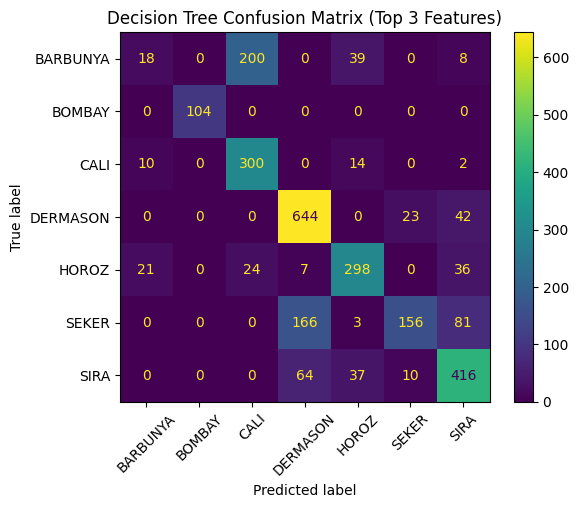

Accuracy: 0.7109805361733382
Balanced Accuracy: 0.6917317856281305
Macro F1: 0.6671741259074926

Classification report:

              precision    recall  f1-score   support

    BARBUNYA       0.37      0.07      0.11       265
      BOMBAY       1.00      1.00      1.00       104
        CALI       0.57      0.92      0.71       326
    DERMASON       0.73      0.91      0.81       709
       HOROZ       0.76      0.77      0.77       386
       SEKER       0.83      0.38      0.52       406
        SIRA       0.71      0.79      0.75       527

    accuracy                           0.71      2723
   macro avg       0.71      0.69      0.67      2723
weighted avg       0.70      0.71      0.68      2723



In [13]:
# 5) Evaluation (Confusion Matrix + metrics)
#5.1 Predict on the test set

y_pred = pipe.predict(X_test)

#5.2 Confusion Matrix

cm = confusion_matrix(y_test, y_pred, labels=pipe.classes_)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=pipe.classes_)

plt.figure(figsize=(8, 6))
disp.plot(xticks_rotation=45)
plt.title("Decision Tree Confusion Matrix (Top 3 Features)")
plt.show()

# 5.3 Metrics
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Balanced Accuracy:", balanced_accuracy_score(y_test, y_pred))
print("Macro F1:", f1_score(y_test, y_pred, average="macro"))

print("\nClassification report:\n")
print(classification_report(y_test, y_pred))


In [15]:
# 6) Optimization (using cross-validation results)
# 6.1 Grid search
param_grid = {
    "clf__max_depth": [3, 5, 7, 10, None],
    "clf__min_samples_split": [2, 5, 10, 20],
    "clf__min_samples_leaf": [1, 2, 5, 10]
}

grid = GridSearchCV(
    estimator=pipe,
    param_grid=param_grid,
    scoring="f1_macro",     # or "balanced_accuracy"
    cv=cv,
    n_jobs=-1
)

grid.fit(X_train, y_train)
print("Best params:", grid.best_params_)
print("Best CV score:", grid.best_score_)

Best params: {'clf__max_depth': None, 'clf__min_samples_leaf': 10, 'clf__min_samples_split': 2}
Best CV score: 0.7982526288174882


In [16]:
# Get the best optimized model
best_model = grid.best_estimator_

# Make predictions using the optimized model
y_pred_opt = best_model.predict(X_test)
from sklearn.metrics import confusion_matrix
import pandas as pd

cm = confusion_matrix(y_test, y_pred_opt)

cm_df = pd.DataFrame(cm,
                     index=best_model.classes_,
                     columns=best_model.classes_)

print("Confusion Matrix (Optimized Model):")
print(cm_df)

Confusion Matrix (Optimized Model):
          BARBUNYA  BOMBAY  CALI  DERMASON  HOROZ  SEKER  SIRA
BARBUNYA       155       0    64         1     36      1     8
BOMBAY           0     104     0         0      0      0     0
CALI            73       0   241         0      8      1     3
DERMASON         0       0     0       620      1     34    54
HOROZ           45       0     0         9    318      0    14
SEKER            1       0     0        54      2    317    32
SIRA             3       0     1        65     13     18   427


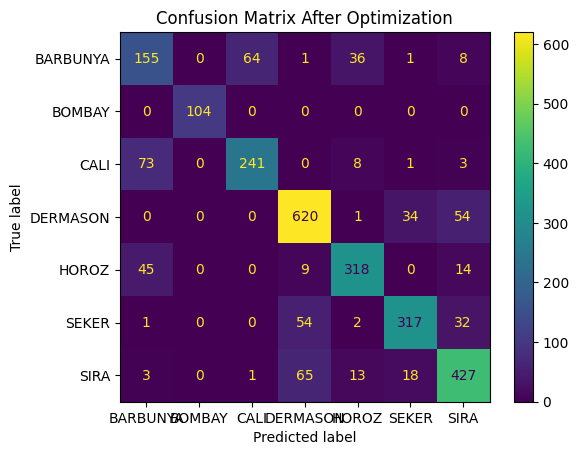

In [ ]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

ConfusionMatrixDisplay.from_predictions(y_test, y_pred_opt)
plt.title("Confusion Matrix After Optimization")
plt.show()

In [17]:
from sklearn.metrics import classification_report, accuracy_score

print("Accuracy:", accuracy_score(y_test, y_pred_opt))
print(classification_report(y_test, y_pred_opt))

Accuracy: 0.8013220712449505
              precision    recall  f1-score   support

    BARBUNYA       0.56      0.58      0.57       265
      BOMBAY       1.00      1.00      1.00       104
        CALI       0.79      0.74      0.76       326
    DERMASON       0.83      0.87      0.85       709
       HOROZ       0.84      0.82      0.83       386
       SEKER       0.85      0.78      0.82       406
        SIRA       0.79      0.81      0.80       527

    accuracy                           0.80      2723
   macro avg       0.81      0.80      0.81      2723
weighted avg       0.80      0.80      0.80      2723

